In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Lazimli kitabxanalari import edirem

In [39]:
import os
files  = os.listdir()
print(files)
# Burda directorydaki fayllara baxiram 

['.git', '.gitignore', '.ipynb_checkpoints', 'AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'HELELİK.ipynb', 'LICENSE', 'NEw', 'NI_hourly.csv', 'P01-PythonBootcampNotebooks-main', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv', 'README.md', 'WheatherConditionDataset.ipynb']


In [40]:
all_dfs = []

for file in os.listdir():
    if file.endswith(".csv") and file != 'pjm_hourly_est.csv':
        df = pd.read_csv(os.path.join(file))
        region = df.columns[1].replace('_MW','')
        df.columns = ["Datetime", "Load"]
        df["regions"] = region
        all_dfs.append(df)
data = pd.concat(all_dfs,ignore_index = True)
data["Datetime"] = pd.to_datetime(data['Datetime'])
data = data.set_index('Datetime').sort_index()
# Burda pjm_hourly_est.csv den basqa mene lazim olan csv filleri gotururem ve birlesdirirem 

In [41]:
data.head()

,Load,regions
Datetime,,
1998-04-01 01:00:00,22259.0,PJM_Load
1998-04-01 02:00:00,21244.0,PJM_Load
1998-04-01 03:00:00,20651.0,PJM_Load
1998-04-01 04:00:00,20421.0,PJM_Load
1998-04-01 05:00:00,20713.0,PJM_Load


In [42]:
data['regions'].unique()

array(['PJM_Load', 'PJME', 'PJMW', 'NI', 'AEP', 'DAYTON', 'DUQ', 'DOM',
       'COMED', 'FE', 'DEOK', 'EKPC'], dtype=object)

In [43]:
data['regions'].value_counts()

regions
PJME        145366
PJMW        143206
DAYTON      121275
AEP         121273
DUQ         119068
DOM         116189
COMED        66497
FE           62874
NI           58450
DEOK         57739
EKPC         45334
PJM_Load     32896
Name: count, dtype: int64

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  32896 non-null  object 
 1   Load      32896 non-null  float64
 2   regions   32896 non-null  object 
dtypes: float64(1), object(2)
memory usage: 771.1+ KB


In [45]:
from sklearn.model_selection import train_test_split
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month
df['dayofweek'] = df['Datetime'].dt.dayofweek
df = df.drop('Datetime',axis  = 1)
X = df.drop('Load',axis = 1)
y =  df['Load']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=15)

#Burda her saat yeni qisaca date time modele cox tesir edir deye ayiriram ki hansi zaman birimi(day,week .etc) daha cox tesir edir modele

In [46]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_reg = ohe.fit_transform(X_train[['regions']])
X_test_reg = ohe.transform(X_test[['regions']])
#Burda regionlarin tipi object oldgugu ucun onehotencoding edirem 

In [47]:
X_train_reg_df = pd.DataFrame(
    X_train_reg.toarray(),
    columns=ohe.get_feature_names_out(),
    index=X_train.index
)
X_test_reg_df = pd.DataFrame(
    X_test_reg.toarray(),
    columns=ohe.get_feature_names_out(),
    index=X_test.index
)
X_train = X_train.drop('regions', axis=1)
X_train = pd.concat([X_train, X_train_reg_df], axis=1)
X_test = X_test.drop('regions', axis=1)
X_test = pd.concat([X_test, X_test_reg_df], axis=1)
# Burada OneHotEncoding mene array-i crs_matrix seklinde qaytardigi ucun onu yeniden arraya cevirib dataya elave edirem,  amma bezi modeller varki
# bunu crs_matrix formatda qebul edir amma arraya cevrilmeyi daha yaxsidir

In [48]:
X_train.head()

,hour,day,month,dayofweek,regions_PJM_Load
11220,16,22,6,1,1.0
6510,9,4,4,5,1.0
23195,18,9,2,2,1.0
2790,8,6,9,6,1.0
22855,14,23,2,2,1.0


In [49]:
import xgboost

In [50]:
from xgboost import XGBRegressor
#burda targetdeki deyisenler continuous oldugu ucun regessor elave etdim classification evezine

In [51]:
xgb = XGBRegressor()

In [52]:
xgb.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [58]:
y_pred = xgb.predict(X_test)

In [64]:
y_pred = xgb.predict(X_test)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1211.6677271030292
RMSE: 2889519.6863240018
R2: 0.9135994458021159


In [93]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.5,
    max_depth=6,
    random_state=42
)

In [94]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
y_pred1 = model.predict(X_test)

In [96]:
print("MAE:", mean_absolute_error(y_test, y_pred1))
print("RMSE:", mean_squared_error(y_test, y_pred1))
print("R2:", r2_score(y_test, y_pred1))

MAE: 997.2824141802955
RMSE: 1884923.1282322556
R2: 0.9436382442139157


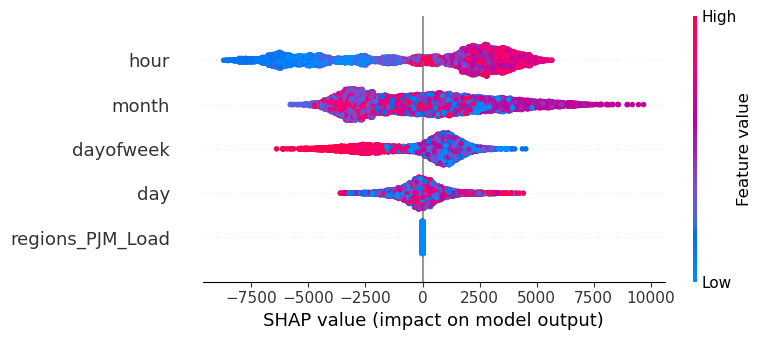

In [97]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

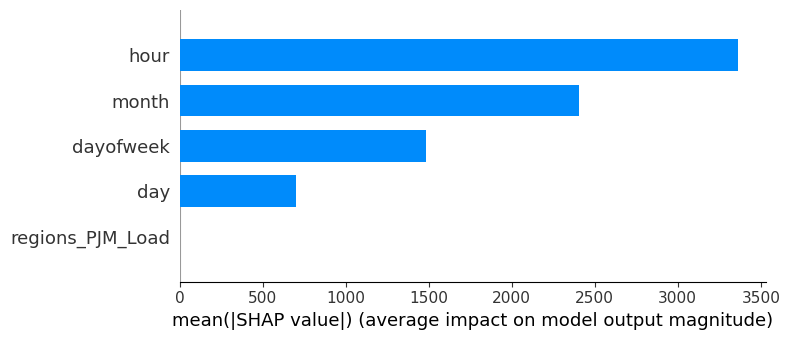

In [112]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [ ]:
#1.  Burda hour dataya cox tesir edir cunki pik saatlar ve gece saatlarinda enerji israfi deyise biler
# 2. 2 ci en cox tesir eden month_dur ozellikle fesiller deyisende enerji israfi hava seraitine gore deyise biler 
# 3. dayofweek bu datada is gunleri ve hefte sonlari istifade edilen enerjini gosterir
# 4. bolgeler enerji israfini ve ya enerjinin cox ve ya az istifade edilmesine tesir etmir ve istesek regionlari sile bilerik

# opsi olaraq demek olar data time series pattern dasiyir